In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
path = 'bung-tomo.jpg'
img = cv.imread(path, 0)

In [3]:
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)
magnitude_spectrum = 20*np.log(np.abs(fshift)+1)

In [4]:
rows, cols = img.shape
crow, ccol = rows//2 , cols//2

mask = np.ones((rows, cols), np.uint8)

r = 10
mask[crow-30-r:crow-30+r, ccol-30-r:ccol-30+r] = 0
mask[crow+30-r:crow+30+r, ccol+30-r:ccol+30+r] = 0

In [5]:
fshift_filtered = fshift * mask
f_ishift = np.fft.ifftshift(fshift_filtered)
img_back = np.fft.ifft2(f_ishift)
img_back = np.abs(img_back)
img_back = np.uint8(np.clip(img_back,0,255))

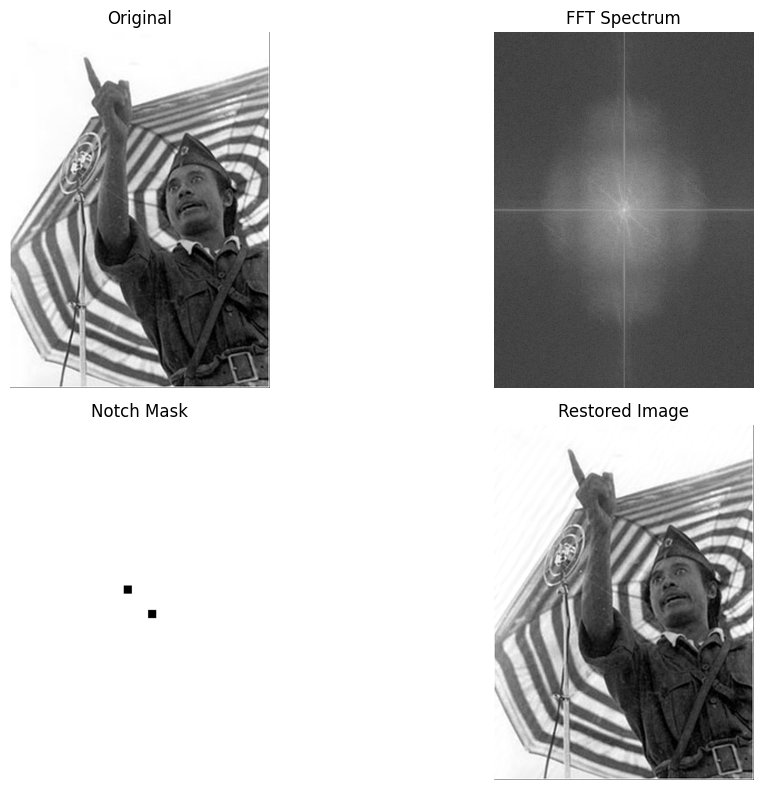

In [6]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title('FFT Spectrum')
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(mask, cmap='gray')
plt.title('Notch Mask')
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(img_back, cmap='gray')
plt.title('Restored Image')
plt.axis('off')

plt.tight_layout()
plt.show()